# Example-08: Generation of test trajectories

In [1]:
# Import

import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Test trajectories at locations can be generated for a given initial condition
# Set uncoupled model

model = Model(path='../config.yaml', model='uncoupled', dtype=dtype, device=device)

# Generate errors

model.make_error(1.0E-3, 1.0E-3)

# Compute transport matrices

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

True


In [4]:
# Set initial condition

state = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

In [5]:
# Initial condition can be propagated using map_transport method

print(torch.allclose(model.map_transport(state, 0, model.size, error=False), model.matrix(0, model.size) @ state))
print(torch.allclose(model.map_transport(state, 0, model.size, error=True), model.turn @ state))

True
True


In [6]:
# Trajectories can be generated by state propagation or using transport matrices
# Without corrector errors, trajectories are the same, but using transport matrices is faster

# Set number of iterations

length = 2**6

# Generate trajectories

trj1 =  model.make_trajectory(state, length, error=True, transport=False)
trj2 =  model.make_trajectory(state, length, error=True, transport=True)
print(trj1.shape)
print(trj2.shape)
print(torch.allclose(trj1, trj2))

torch.Size([59, 64, 4])
torch.Size([59, 64, 4])
True


torch.Size([59, 4096, 4])


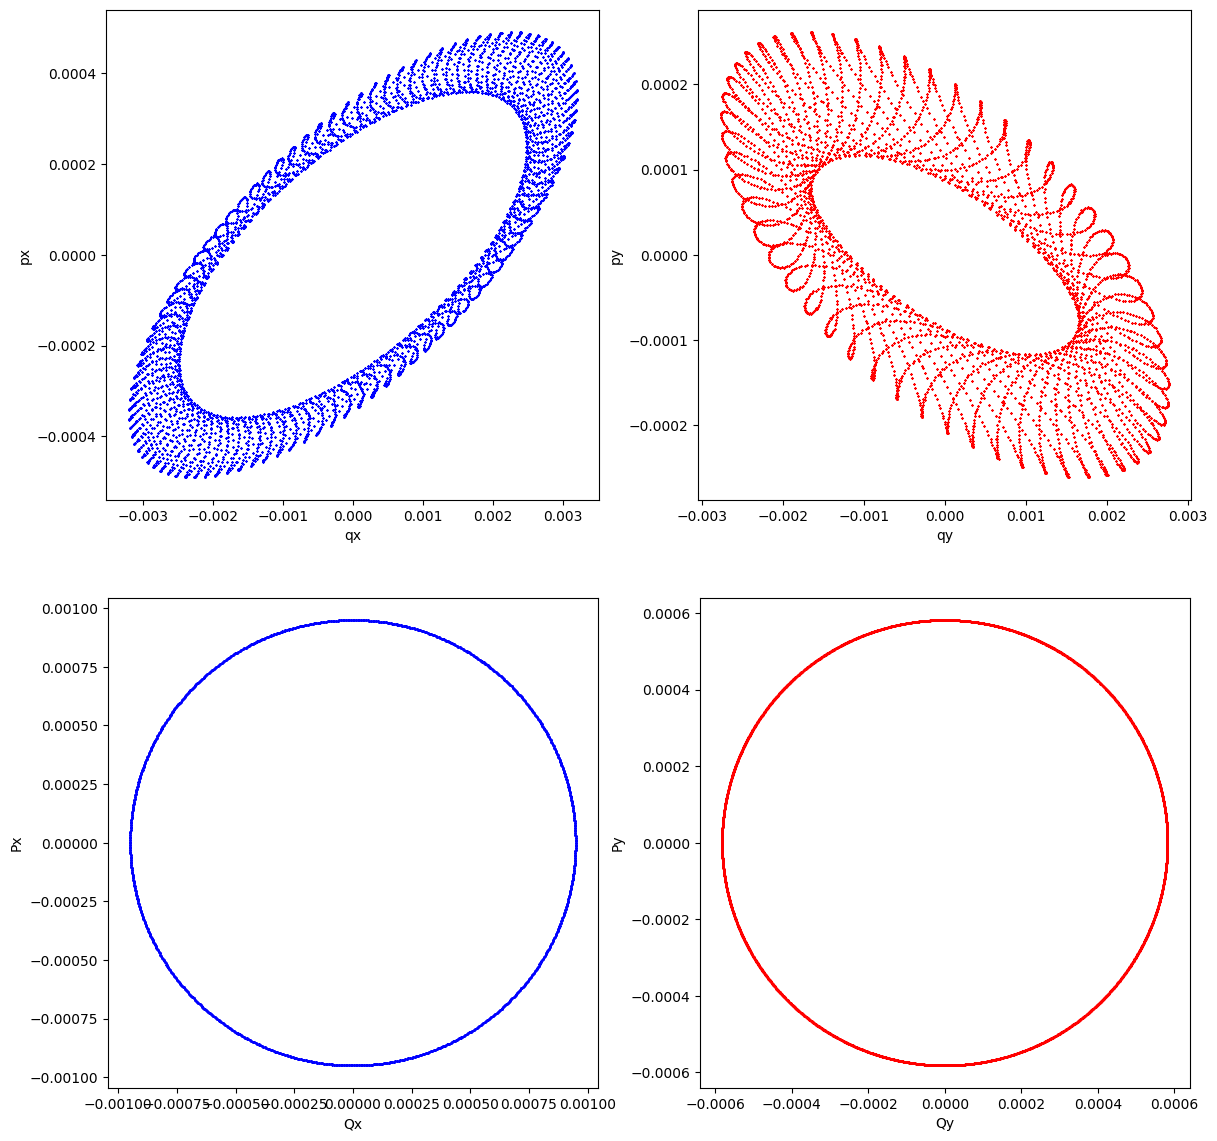

2.597810231309728e-18
8.64474874347288e-19


In [7]:
# Generate trajectories using transport matrices

length = 2**12
trajectory =  model.make_trajectory(state, length, error=True, transport=True)
print(trajectory.shape)

# Plot trajectory and floquet trajectory for given location index

index = 0

qx, px, qy, py = trajectory[index].T.cpu().numpy()
Qx, Px, Qy, Py = (model.out_normal[index].inverse() @ trajectory[index].T).cpu().numpy()

plt.figure(figsize=(2*7, 2*7))

# qx-px

ax1 = plt.subplot(221)
ax1.scatter(qx, px, marker='x', s=1, color='blue')
ax1.set_xlabel('qx')
ax1.set_ylabel('px')
ax1.set_aspect('auto')

# qy-py

ax2 = plt.subplot(222)
ax2.scatter(qy, py, marker='x', s=1, color='red')
ax2.set_xlabel('qy')
ax2.set_ylabel('py')
ax2.set_aspect('auto')

# Qx-Px

ax3 = plt.subplot(223)
ax3.scatter(Qx, Px, marker='x', s=1, color='blue')
ax3.set_xlabel('Qx')
ax3.set_ylabel('Px')
ax3.set_aspect('equal')

# Qy-Py

ax4 = plt.subplot(224)
ax4.scatter(Qy, Py, marker='x', s=1, color='red')
ax4.set_xlabel('Qy')
ax4.set_ylabel('Py')
ax4.set_aspect('equal')

plt.show()

# Conservation of invariants

print((Qx**2 + Px**2).std().item())
print((Qy**2 + Py**2).std().item())

In [8]:
# Trajectories are generated at all locations

print(model.size)
print(trajectory.shape)
print()

# Trajectories at montor locations

print(model.monitor_count)
print(trajectory[model.monitor_index].shape)
print()

59
torch.Size([59, 4096, 4])

54
torch.Size([54, 4096, 4])

